# Проект: A/B-тестирование в мобильной игре "Cookie Cats" 

### Описание проекта
В этом проекте мы анализируем результаты A/B-теста популярной мобильной игры-головоломки **Cookie Cats**. 
По мере прохождения игры пользователи сталкиваются с «воротами» (gates), которые заставляют их ждать определенное время или совершить внутриигровую покупку, чтобы продолжить прогресс. 

### Цель исследования
Основная задача — определить, как перенос первых ворот с **30-го уровня** на **40-й** влияет на удержание игроков (Retention). 

### Метрики
Мы сфокусируемся на двух ключевых метриках:
1. **Retention 1 day**: процент игроков, которые вернулись в игру через 1 день после установки.
2. **Retention 7 days**: процент игроков, которые вернулись в игру через 7 дней после установки.

### Стек технологий
* **Python** (Pandas, NumPy, SciPy, Statsmodels)
* **Визуализация**: Matplotlib, Seaborn
* **Методы**: Статистические тесты (Chi-Square), Bootstrap-анализ, Анализ мощности.

### Проверка данных


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
# Загружаем данные
df = pd.read_csv('data\cookie_cats.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


- 90189 записей
- пропусков нет
- типы данных актуальные

### Проверка дизайна теста
- нужно убедиться, что группы gate_30 и gate_40 распределены равномерно и в данных нет критических перекосов.

In [4]:
df_versions = df.groupby('version').count()
df_versions.head()

,userid,sum_gamerounds,retention_1,retention_7
version,,,,
gate_30,44700,44700,44700,44700
gate_40,45489,45489,45489,45489


- **группы выглядят сбалансированно**: gate_30 - 49.5%, gate_40 - 50.5%

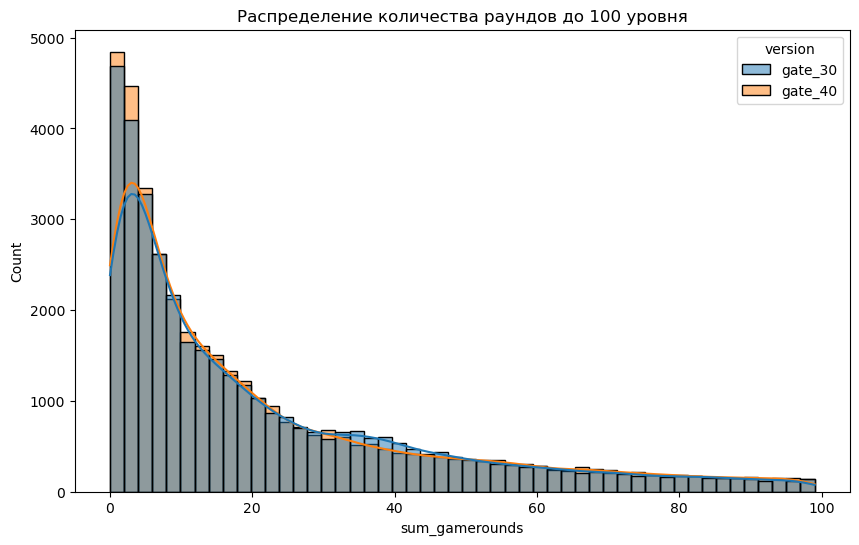

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['sum_gamerounds'] < 100], 
             x='sum_gamerounds', 
             hue='version', 
             kde=True, 
             bins=50)
plt.title('Распределение количества раундов до 100 уровня')
plt.show()


### Визуализация распределения игровых раундов

Для понимания поведения игроков построим гистограмму распределения количества пройденных раундов. Поскольку основная масса пользователей совершает небольшое количество игровых сессий, ограничим график первыми **100 раундами**.

**Анализ графика:**
* **Эффект «воронки»:** Наблюдается резкий всплеск в районе 0-5 раундов. Это пользователи, которые покинули игру практически сразу после установки.
* **Релевантность данных:** Игроки, не достигшие 30-го уровня, технически не столкнулись с экспериментальным изменением (воротами). 
* **Идентичность групп:** Распределения обеих групп (`gate_30` и `gate_40`) на начальных этапах практически накладываются друг на друга, что подтверждает корректность разделения трафика.


### Анализ мощности (Power Analysis)

Перед проведением статистических тестов необходимо определить **базовый уровень конверсии** (baseline) и оценить, какую минимальную разницу в удержании мы сможем зафиксировать при текущем размере выборки.

Для расчета мы будем использовать:
* **$\alpha$ (уровень значимости) = 0.05**: вероятность ложноположительного результата.
* **$1-\beta$ (мощность) = 0.80**: вероятность обнаружить реальный эффект.

В качестве базовой метрики возьмем среднее значение `retention_1` по всему датасету. Поскольку данные представлены в формате `bool`, метод `.mean()` вернет нам искомую пропорцию вернувшихся игроков.


In [9]:
p1_base = df['retention_1'].mean()
print(f"базовое значение удержания первого дня: {p1_base}")

базовое значение удержания первого дня: 0.4452095044850259


In [11]:
from statsmodels.stats.power import NormalIndPower

analysis =NormalIndPower()
# Вычисляем эффект, который мы можем поймать
effect_size = analysis.solve_power(nobs1=44700, alpha=0.05, power=0.8, ratio=1)
print(f"Effect Size: {effect_size}")


Effect Size: 0.01873977801278678


* **Результат 0.0187** сигнализирует, что **тест заметит** даже слабое **различие** между группами

### Поиск и анализ "нулевых" игроков

Игроки, которые установили игру, но не сыграли ни одного раунда (`sum_gamerounds == 0`), являются важным сегментом для анализа. 
1. **Технический аудит**: Слишком большой процент таких игроков может указывать на баги при запуске или проблемы с совместимостью.
2. **Очистка данных**: Эти пользователи не дошли до ворот (30 или 40 уровень), поэтому они не несут информации о влиянии эксперимента. 
3. **Проверка сплитования**: Мы должны убедиться, что доля таких игроков примерно одинакова в обеих группах, чтобы исключить перекос в качестве трафика.


In [13]:
# Находим игроков с 0 раундов
zero_rounds = df[df['sum_gamerounds'] == 0]

# Считаем количество таких игроков по группам
zero_counts = zero_rounds.groupby('version')['userid'].count()

# Для наглядности посчитаем общую долю (в процентах) от каждой группы
total_counts = df.groupby('version')['userid'].count()
zero_percent = (zero_counts / total_counts) * 100

print("Количество 'нулевых' игроков:")
print(zero_counts)
print("\nДоля 'нулевых' игроков в каждой группе (%):")
print(zero_percent)


Количество 'нулевых' игроков:
version
gate_30    1937
gate_40    2057
Name: userid, dtype: int64

Доля 'нулевых' игроков в каждой группе (%):
version
gate_30    4.333333
gate_40    4.521972
Name: userid, dtype: float64


### Результаты проверки на "нулевых" игроков

После анализа пользователей, не сыгравших ни одного раунда, получены следующие данные:
* **gate_30**: ~4.33% от общего числа группы.
* **gate_40**: ~4.52% от общего числа группы.

**Вывод:** Доля неактивных пользователей в обеих группах практически идентична (разница менее 0.2%). Это подтверждает корректность работы системы распределения игроков и позволяет нам переходить к анализу основной метрики — Retention — без опасения, что одна из групп "замусорена" сильнее другой.


### Анализ Retention 1 day

In [16]:
retention_1day = df.groupby('version')['retention_1'].mean()
print(retention_1day)

version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64


In [20]:
val_30 = retention_1day['gate_30']
val_40 = retention_1day['gate_40']
lift = (val_40 - val_30) / val_30 * 100
print(f"Относительное изменение: {lift:.2f}%")

Относительное изменение: -1.32%


- **перенос ворот с 30 на 40 уровень** привел к небольшому **"проседанию" возвращаемости** игроков на **первый день**

#### Z-тест и P-value

In [22]:
from statsmodels.stats.proportion import proportions_ztest

# Считаем количество вернувшихся (True) и общее количество по группам
counts = df.groupby('version')['retention_1'].sum()
nobs = df.groupby('version')['retention_1'].count()

# Запускаем Z-тест
z_stat, p_val = proportions_ztest(count=counts, nobs=nobs)

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")


Z-статистика: 1.7841
p-value: 0.0744


#### Статистическая проверка гипотез (Z-тест)
Чтобы понять, является ли падение Retention на 1.32% случайным шумом или закономерным результатом переноса ворот, проведем **Z-тест для долей**. 
**Параметры теста:**
* **Нулевая гипотеза ($H_0$):** Разницы в удержании между игроками с воротами на 30 и 40 уровнях нет.
* **Альтернативная гипотеза ($H_1$):** Существует статистически значимая разница в удержании.
* **Уровень значимости ($\alpha$):** 0.05 (стандарт для индустрии).

**Результаты:**
* **Z-статистика:** 1.7841
* **p-value:** 0.0744

Наблюдаем: снижение на 1.32%, не значимо (p-value > 0.05), требуется проверить долгосрочное удержание

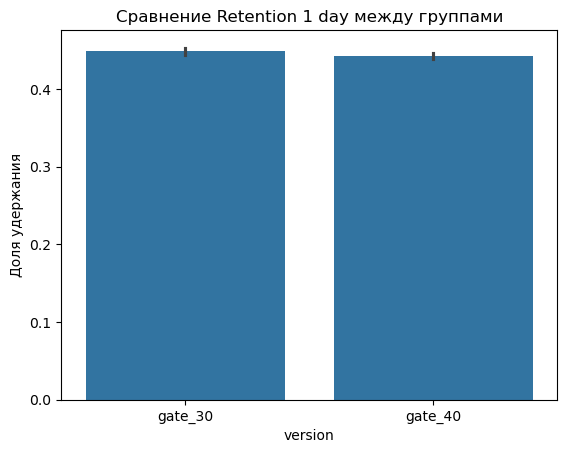

In [27]:

sns.barplot(x='version', y='retention_1', data=df)

plt.title('Сравнение Retention 1 day между группами')
plt.ylabel('Доля удержания')
plt.show()


#### Интерпретация  визуализации Retention 1 day
На графике 1-го дня мы не видим четкого разделения между группами. На этом этапе нельзя утверждать, что изменение ворот как-то повлияло на игроков.

## Анализ Retention 7 day

In [23]:
retention_7day = df.groupby('version')['retention_7'].mean()
print(retention_7day)

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64


In [24]:
val7_30 = retention_7day['gate_30']
val7_40 = retention_7day['gate_40']
lift = (val7_40 - val7_30) / val7_30 * 100
print(f"Относительное изменение: {lift:.2f}%")

Относительное изменение: -4.31%


In [25]:
from statsmodels.stats.proportion import proportions_ztest

# Считаем количество вернувшихся (True) и общее количество по группам
counts_7 = df.groupby('version')['retention_7'].sum()
nobs_7 = df.groupby('version')['retention_7'].count()

# Запускаем Z-тест
z_stat, p_val = proportions_ztest(count=counts_7, nobs=nobs_7)

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")


Z-статистика: 3.1644
p-value: 0.0016




**Результаты расчетов:**
* **Контрольная группа (gate_30):** 19.02%
* **Тестовая группа (gate_40):** 18.20%
* **Относительное изменение (Lift):** **-4.31%** 

**Статистический тест (Z-test):**
* **Z-статистика:** 3.1644
* **p-value:** **0.0016**

**Вывод:**
Так как **p-value (0.0016) < 0.05**, мы отвергаем нулевую гипотезу. Падение удержания на 7-й день является **статистически значимым**. Перенос ворот с 30-го на 40-й уровень отрицательно сказывается на том, как часто игроки возвращаются в приложение спустя неделю.


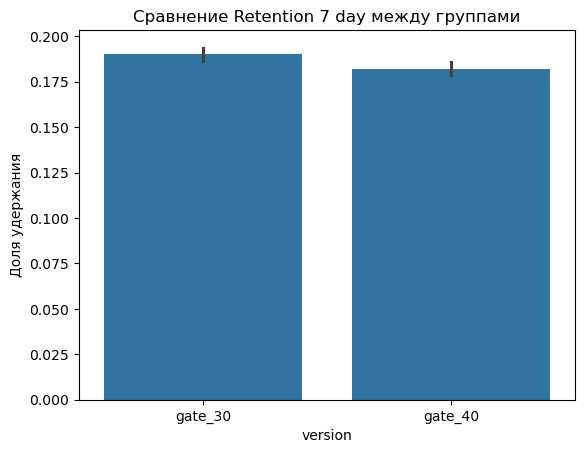

In [26]:

sns.barplot(x='version', y='retention_7', data=df)

plt.title('Сравнение Retention 7 day между группами')
plt.ylabel('Доля удержания')
plt.show()


#### Интерпретация визуализации Retention 7-го дня
График подтверждает результаты статистического теста, но требует внимательного прочтения:
* **Визуальное сходство**: На первый взгляд разница между `gate_30` и `gate_40` кажется незначительной. Это объясняется тем, что абсолютное падение составляет около 1 процентного пункта (с 19.0% до 18.2%).
* **Бизнес-эффект**: Несмотря на визуальную близость столбиков, относительное падение удержания на **4.3%** является критическим для экономики игры. 
**Итоговый вердикт:** Статистика и визуализация (через доверительные интервалы) солидарны — перенос ворот на 40 уровень статистически значимо ухудшает удержание игроков через неделю после установки.

# Итоговые выводы по A/B тесту (Executive Summary)

**Цель эксперимента:** Оценить влияние переноса игровых ворот (Gate) с 30-го на 40-й уровень на удержание пользователей (Retention).

---

### 1. Удержание 1-го дня (Retention 1 day)
* **Результат:** Наблюдается небольшое снижение удержания в тестовой группе (`gate_40`) на **1.32%** относительно контрольной.
* **Статистическая значимость:** Результат **не значим** ($p$-value = 0.0744 > 0.05). 
* **Интерпретация:** На краткосрочном горизонте (1 день) мы не видим уверенного негативного влияния. Текущая разница может быть результатом естественного "шума" в данных.

### 2. Удержание 7-го дня (Retention 7 day) 
* **Результат:** Зафиксировано падение удержания на **4.31%** в группе `gate_40`.
* **Статистическая значимость:** Результат **статистически значим** ($p$-value = 0.0016 < 0.05).
* **Интерпретация:** Перенос ворот на 40-й уровень достоверно и ощутимо ухудшает возвращаемость игроков через неделю после начала игры.

---

## Финальная рекомендация

На основании проведенного анализа рекомендуется **отказаться от переноса ворот на 40-й уровень** и оставить их на **30-м уровне**. 

**Обоснование:** Несмотря на то, что в первый день эффект выражен слабо, к седьмому дню отрицательное влияние становится математически доказанным. Удержание 7-го дня — это критическая метрика для LTV (пожизненной ценности) игрока. Потеря более 4% лояльной аудитории приведет к долгосрочному снижению доходов, которое не перекроется потенциальной выгодой от более позднего ограничения контента.
